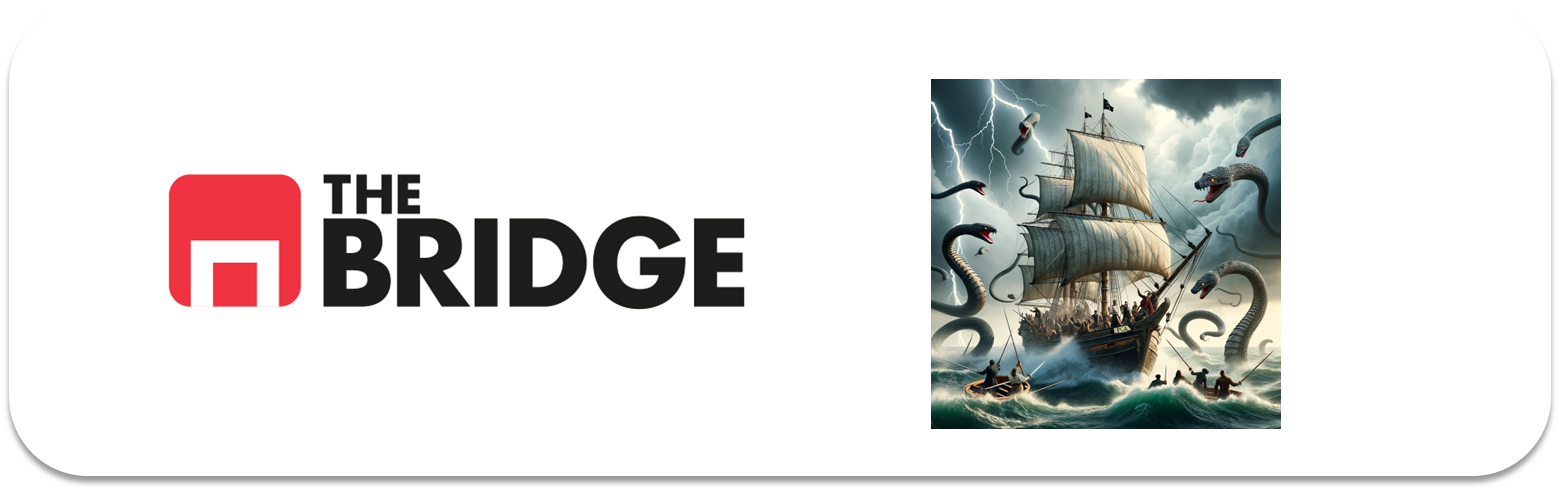

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [3]:
olivetti = fetch_olivetti_faces()

X = olivetti.data
y = olivetti.target

df = pd.DataFrame(X)
df["target"] = y

df.head()

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [4]:
df.shape

(400, 4097)

In [5]:
df["target"].value_counts()

target
0     10
1     10
2     10
3     10
4     10
5     10
6     10
7     10
8     10
9     10
10    10
11    10
12    10
13    10
14    10
15    10
16    10
17    10
18    10
19    10
20    10
21    10
22    10
23    10
24    10
25    10
26    10
27    10
28    10
29    10
30    10
31    10
32    10
33    10
34    10
35    10
36    10
37    10
38    10
39    10
Name: count, dtype: int64

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=80,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape

((320, 4096), (80, 4096))

In [7]:
modelo = SVC(kernel="linear", random_state=42)

scores = cross_val_score(
    modelo,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Balanced accuracy media (CV):", scores.mean())

Balanced accuracy media (CV): 0.9625


In [8]:
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

baseline_test = balanced_accuracy_score(y_test, y_pred)

print("Balanced accuracy en test:", baseline_test)

Balanced accuracy en test: 0.975


In [9]:
baseline_cv = scores.mean()
baseline_test

0.975

### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [10]:
pca = PCA()

pca.fit(X_train)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [11]:
n_features = X_train.shape[1]

proporciones = [0.002, 0.005, 0.01, 0.015, 0.02, 0.025]

componentes = [int(n_features * p) for p in proporciones]

componentes

[8, 20, 40, 61, 81, 102]

In [12]:
resultados = []

for n in componentes:

    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    modelo = SVC(kernel="linear", random_state=42)

    scores = cross_val_score(
        modelo,
        X_train_pca,
        y_train,
        cv=5,
        scoring="balanced_accuracy"
    )

    cv_score = scores.mean()

    modelo.fit(X_train_pca, y_train)

    y_pred = modelo.predict(X_test_pca)

    test_score = balanced_accuracy_score(y_test, y_pred)

    compression_ratio = n / n_features

    diff_cv = cv_score - baseline_cv
    diff_test = test_score - baseline_test

    resultados.append(
        [n, cv_score, test_score, compression_ratio, diff_cv, diff_test]
    )

In [13]:
df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "n_components",
        "cv_score",
        "test_score",
        "compression_ratio",
        "diff_cv",
        "diff_test"
    ]
)

df_resultados

,n_components,cv_score,test_score,compression_ratio,diff_cv,diff_test
0,8,0.8075,0.8250,0.001953,-0.1550,-0.1500
1,20,0.9500,0.9375,0.004883,-0.0125,-0.0375
2,40,0.9575,0.9625,0.009766,-0.0050,-0.0125
3,61,0.9575,0.9750,0.014893,-0.0050,0.0000
4,81,0.9600,0.9750,0.019775,-0.0025,0.0000
5,102,0.9625,0.9750,0.024902,0.0000,0.0000


In [14]:
df_validos = df_resultados[
    (df_resultados["diff_cv"] >= -0.03) &
    (df_resultados["diff_test"] >= -0.03)
]

df_validos

,n_components,cv_score,test_score,compression_ratio,diff_cv,diff_test
2,40,0.9575,0.9625,0.009766,-0.0050,-0.0125
3,61,0.9575,0.9750,0.014893,-0.0050,0.0000
4,81,0.9600,0.9750,0.019775,-0.0025,0.0000
5,102,0.9625,0.9750,0.024902,0.0000,0.0000


In [15]:
mejor_modelo = df_validos.sort_values("n_components").iloc[0]

mejor_modelo

n_components         40.000000
cv_score              0.957500
test_score            0.962500
compression_ratio     0.009766
diff_cv              -0.005000
diff_test            -0.012500
Name: 2, dtype: float64

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [16]:
componentes = [4, 13, 22, 31, 40]


resultados_unzip = []

for n in componentes:

    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    X_train_rec = pca.inverse_transform(X_train_pca)
    X_test_rec = pca.inverse_transform(X_test_pca)

    modelo = SVC(kernel="linear", random_state=42)

    scores = cross_val_score(
        modelo,
        X_train_rec,
        y_train,
        cv=5,
        scoring="balanced_accuracy"
    )

    cv_score = scores.mean()

    modelo.fit(X_train_rec, y_train)

    y_pred = modelo.predict(X_test_rec)

    test_score = balanced_accuracy_score(y_test, y_pred)

    compression_ratio = n / X_train.shape[1]

    resultados_unzip.append(
        [n, cv_score, test_score, compression_ratio]
    )

In [17]:
df_unzip = pd.DataFrame(
    resultados_unzip,
    columns=[
        "n_components",
        "cv_score",
        "test_score",
        "compression_ratio"
    ]
)

df_unzip

,n_components,cv_score,test_score,compression_ratio
0,4,0.6025,0.5250,0.000977
1,13,0.9150,0.9000,0.003174
2,22,0.9525,0.9625,0.005371
3,31,0.9500,0.9625,0.007568
4,40,0.9575,0.9625,0.009766


### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

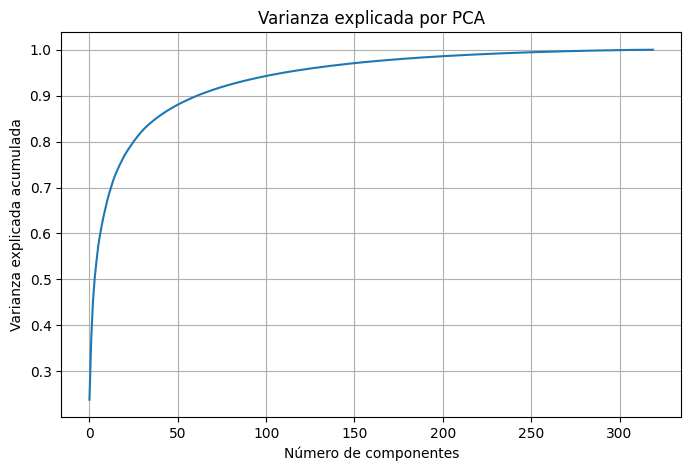

In [20]:
pca = PCA()
pca.fit(X_train)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(varianza_acumulada)

plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada por PCA")

plt.grid()

plt.show()

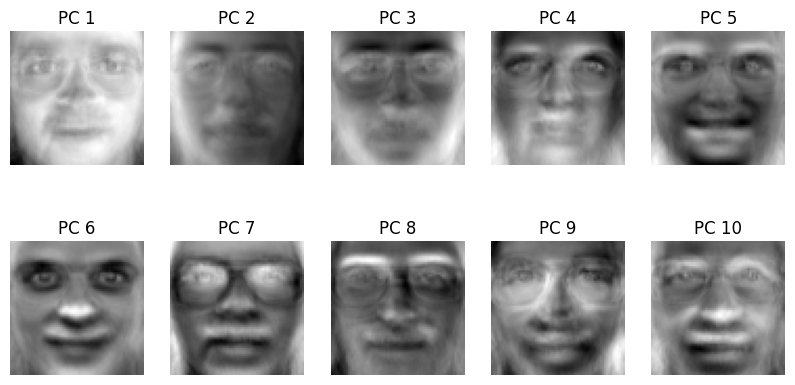

In [22]:
pca = PCA(n_components=10)

pca.fit(X_train)

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    
    eigenface = pca.components_[i].reshape(64,64)
    
    ax.imshow(eigenface, cmap="gray")
    
    ax.set_title(f"PC {i+1}")
    
    ax.axis("off")

plt.show()

In [23]:
pca = PCA(n_components=40)

X_train_pca = pca.fit_transform(X_train)

X_reconstruida = pca.inverse_transform(X_train_pca)

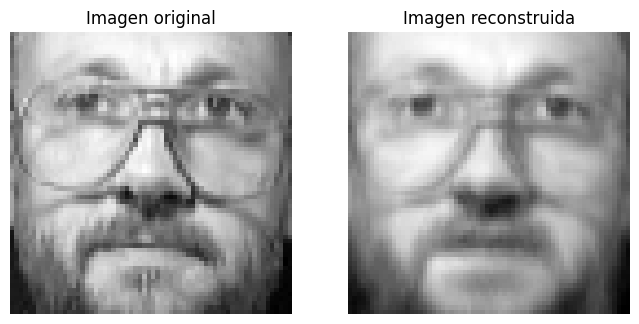

In [24]:
fig, axes = plt.subplots(1,2, figsize=(8,4))

axes[0].imshow(X_train.iloc[0].values.reshape(64,64), cmap="gray")
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(X_reconstruida[0].reshape(64,64), cmap="gray")
axes[1].set_title("Imagen reconstruida")
axes[1].axis("off")

plt.show()

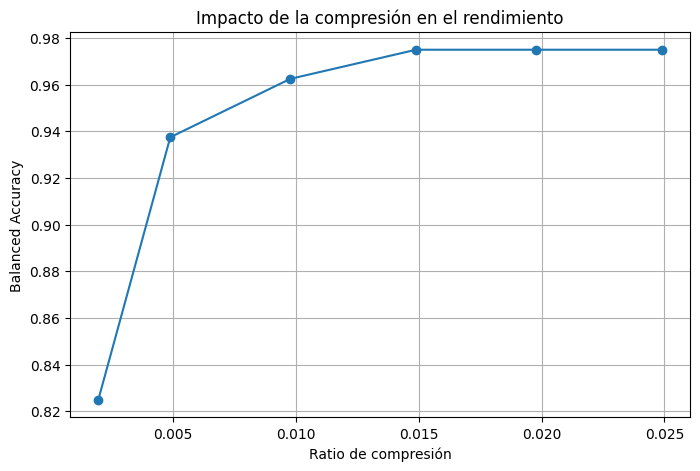

In [25]:
plt.figure(figsize=(8,5))

plt.plot(df_resultados["compression_ratio"], df_resultados["test_score"], marker="o")

plt.xlabel("Ratio de compresión")
plt.ylabel("Balanced Accuracy")
plt.title("Impacto de la compresión en el rendimiento")

plt.grid()

plt.show()